# L4.1 — RNNs and the Long-Context Barrier

Hands-on notebook for the lesson [`4-1-rnn-context.mdx`](../../llm-quest-theory/level-4/4-1-rnn-context.mdx).

> **Learning objectives**
> - Implement a vanilla RNN from scratch and run it step-by-step.
> - Train an RNN on a **copy task** (remember the first token) and see performance collapse as the sequence grows.
> - Measure the vanishing-gradient effect along the time axis.
> - Compare against an LSTM to see where gating helps and where it still runs out.

## Connection to the theory
Covers **§1–§6** of the source `.mdx`. Every barrier we feel in this notebook is exactly what self-attention (lesson 4-2) was invented to dissolve.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cpu"
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline
print("torch", torch.__version__)

torch 2.2.2


## 1. A vanilla RNN by hand

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b)$$

Sequential — step `t` depends on step `t-1`. That is the seed of both its memory and its training pain.

In [2]:
def rnn_forward(xs, W_xh, W_hh, b, h0=None):
    """xs: (T, d_in)   returns list of hidden states h_0..h_T."""
    T, _ = xs.shape
    h = np.zeros(W_hh.shape[0]) if h0 is None else h0
    history = [h.copy()]
    for t in range(T):
        h = np.tanh(W_hh @ h + W_xh @ xs[t] + b)
        history.append(h.copy())
    return history

# Tiny example: 3 time steps, 2-dim input, 4 hidden units.
d_in, d_hid = 2, 4
W_xh = np.random.randn(d_hid, d_in) * 0.3
W_hh = np.random.randn(d_hid, d_hid) * 0.3
b    = np.zeros(d_hid)
xs   = np.array([[1.0, 0.0], [0.0, 1.0], [-0.5, 0.5]])

history = rnn_forward(xs, W_xh, W_hh, b)
for t, h in enumerate(history):
    print(f"h_{t} = {np.round(h, 3)}")

h_0 = [0. 0. 0. 0.]
h_1 = [ 0.148  0.192 -0.07   0.441]
h_2 = [-0.083  0.309 -0.259  0.092]
h_3 = [-0.01   0.066  0.086 -0.22 ]


## 2. The copy task — the classic stress test
Input: a random sequence of `T` one-hot tokens. Task: predict token `0` after seeing token `T-1`. If the model can't, it cannot preserve long-range information.

In [3]:
VOCAB = 6          # 6 distinct symbols

def make_copy_batch(batch_size, T, vocab=VOCAB, rng=None):
    rng = rng or np.random.default_rng()
    first = rng.integers(0, vocab, size=batch_size)
    rest  = rng.integers(0, vocab, size=(batch_size, T - 1))
    tokens = np.concatenate([first[:, None], rest], axis=1)   # (B, T)
    # One-hot encode
    one_hot = np.eye(vocab)[tokens]                            # (B, T, vocab)
    return torch.tensor(one_hot, dtype=torch.float32), torch.tensor(first, dtype=torch.long)

X, y = make_copy_batch(batch_size=4, T=5)
print("X shape:", X.shape)
print("y     :", y.tolist(), "  (first tokens of each sequence)")

X shape: torch.Size([4, 5, 6])
y     : [1, 0, 4, 3]   (first tokens of each sequence)


## 3. A tiny RNN classifier in PyTorch
Read the whole sequence, use the **final** hidden state to predict the first token.

In [4]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab, hidden=32, cell="rnn"):
        super().__init__()
        if cell == "rnn":
            self.rnn = nn.RNN(vocab, hidden, batch_first=True, nonlinearity="tanh")
        elif cell == "lstm":
            self.rnn = nn.LSTM(vocab, hidden, batch_first=True)
        self.head = nn.Linear(hidden, vocab)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1])

def train_and_eval(cell, T, hidden=32, steps=800, batch=64, lr=5e-3):
    torch.manual_seed(SEED)
    model = RNNClassifier(VOCAB, hidden=hidden, cell=cell)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    rng = np.random.default_rng(SEED + T)
    losses = []
    for step in range(steps):
        X, y = make_copy_batch(batch, T, rng=rng)
        opt.zero_grad()
        logits = model(X)
        loss   = loss_fn(logits, y)
        loss.backward(); opt.step()
        losses.append(loss.item())
    # Final eval on a fresh batch
    X, y = make_copy_batch(512, T, rng=rng)
    acc = (model(X).argmax(1) == y).float().mean().item()
    return model, losses, acc

## 4. Sweep sequence length: at what point does the RNN give up?

In [5]:
T_list = [5, 10, 20, 40, 80]
rnn_acc,  rnn_loss  = [], []
lstm_acc, lstm_loss = [], []
for T in T_list:
    _, lr_hist, lr_acc = train_and_eval("rnn",  T, steps=600)
    _, ll_hist, ll_acc = train_and_eval("lstm", T, steps=600)
    rnn_acc.append(lr_acc); lstm_acc.append(ll_acc)
    rnn_loss.append(lr_hist); lstm_loss.append(ll_hist)
    print(f"T={T:>3}  RNN acc={lr_acc:.3f}   LSTM acc={ll_acc:.3f}   (random baseline = {1/VOCAB:.3f})")

T=  5  RNN acc=1.000   LSTM acc=1.000   (random baseline = 0.167)
T= 10  RNN acc=1.000   LSTM acc=0.512   (random baseline = 0.167)
T= 20  RNN acc=0.553   LSTM acc=0.143   (random baseline = 0.167)
T= 40  RNN acc=0.174   LSTM acc=0.156   (random baseline = 0.167)
T= 80  RNN acc=0.166   LSTM acc=0.182   (random baseline = 0.167)


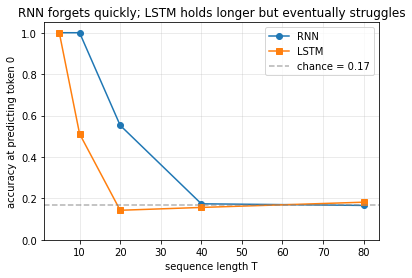

In [6]:
fig, ax = plt.subplots()
ax.plot(T_list, rnn_acc,  "o-", label="RNN")
ax.plot(T_list, lstm_acc, "s-", label="LSTM")
ax.axhline(1 / VOCAB, linestyle="--", color="gray", alpha=0.6, label=f"chance = {1/VOCAB:.2f}")
ax.set_xlabel("sequence length T"); ax.set_ylabel("accuracy at predicting token 0")
ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); ax.legend()
ax.set_title("RNN forgets quickly; LSTM holds longer but eventually struggles")
plt.show()

## 5. Measuring the vanishing gradient directly
Given the trained RNN, compute the norm of `∂h_T/∂h_t` at each time step. If it decays geometrically toward `t = 0`, the model physically cannot propagate information that far.

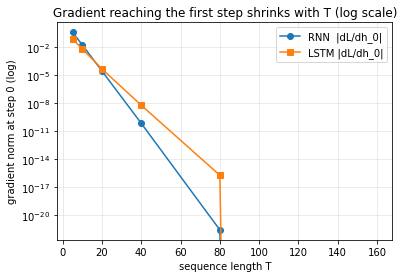

In [7]:
def measure_grad_flow(T=60, hidden=32):
    torch.manual_seed(SEED)
    rnn = nn.RNN(VOCAB, hidden, batch_first=True, nonlinearity="tanh")
    # Build a random sequence and track hidden states as leaf tensors
    rng = np.random.default_rng(SEED)
    tokens = rng.integers(0, VOCAB, size=T)
    x = torch.tensor(np.eye(VOCAB)[tokens], dtype=torch.float32).unsqueeze(0)
    out, _ = rnn(x)                                     # (1, T, hidden)
    target = out[0, -1].sum()
    # For each intermediate t, compute |dh_T / dh_t| via autograd
    norms = []
    for t in range(T):
        x.grad = None
        out, _ = rnn(x)
        h_t = out[0, t]
        grads = torch.autograd.grad(outputs=out[0, -1].sum(),
                                    inputs=h_t, retain_graph=True,
                                    allow_unused=True)[0]
        norms.append(0.0 if grads is None else float(grads.norm()))
    return np.array(norms)

# Easier alternative: feed a learnable h0 and watch ||dL/dh0|| as T grows.
def grad_at_start(cell, T, hidden=32):
    torch.manual_seed(SEED)
    if cell == "rnn":
        net = nn.RNN(VOCAB, hidden, batch_first=True, nonlinearity="tanh")
    else:
        net = nn.LSTM(VOCAB, hidden, batch_first=True)
    X, y = make_copy_batch(1, T, rng=np.random.default_rng(SEED))
    if cell == "rnn":
        h0 = torch.zeros(1, 1, hidden, requires_grad=True)
        out, _ = net(X, h0)
    else:
        h0 = torch.zeros(1, 1, hidden, requires_grad=True)
        c0 = torch.zeros(1, 1, hidden, requires_grad=True)
        out, _ = net(X, (h0, c0))
    out[0, -1].sum().backward()
    return float(h0.grad.norm())

Ts = [5, 10, 20, 40, 80, 160]
rnn_grads  = [grad_at_start("rnn",  T) for T in Ts]
lstm_grads = [grad_at_start("lstm", T) for T in Ts]

fig, ax = plt.subplots()
ax.plot(Ts, rnn_grads,  "o-", label="RNN  |dL/dh_0|")
ax.plot(Ts, lstm_grads, "s-", label="LSTM |dL/dh_0|")
ax.set_xlabel("sequence length T"); ax.set_ylabel("gradient norm at step 0 (log)")
ax.set_yscale("log"); ax.grid(alpha=0.3, which="both"); ax.legend()
ax.set_title("Gradient reaching the first step shrinks with T (log scale)")
plt.show()

## 6. The parallelisation wall
Because `h_t` needs `h_{t-1}`, the forward pass is inherently sequential. Measure wall-clock time vs. sequence length on a single CPU and compare to what a vectorized attention block could do.

In [8]:
import time
hidden = 128
sizes = [100, 400, 1600]
rnn = nn.RNN(VOCAB, hidden, batch_first=True)

for T in sizes:
    X, _ = make_copy_batch(1, T, rng=np.random.default_rng(0))
    t0 = time.time()
    for _ in range(3):
        with torch.no_grad():
            _ = rnn(X)
    dt = (time.time() - t0) / 3
    print(f"T={T:>4}  RNN forward ~ {1000*dt:.1f} ms  (scales ~linearly with T)")

T= 100  RNN forward ~ 5.8 ms  (scales ~linearly with T)
T= 400  RNN forward ~ 19.9 ms  (scales ~linearly with T)
T=1600  RNN forward ~ 89.4 ms  (scales ~linearly with T)


## 7. Quick checks

In [9]:
# RNN should crush short sequences, then struggle on long ones
assert rnn_acc[0]  > 0.9, "RNN should solve short-context copy task"
assert rnn_acc[-1] < rnn_acc[0], "RNN accuracy should drop as T grows"
# LSTM should hold up better on long sequences
assert lstm_acc[-1] >= rnn_acc[-1] - 0.05, "LSTM should not be much worse than RNN at long T"
# Gradient at h_0 shrinks for long T
assert rnn_grads[0] / (rnn_grads[-1] + 1e-30) > 10, "RNN gradient at h_0 must vanish meaningfully"
print("OK — RNN memory is limited, LSTM is better, gradients vanish with depth in time.")

OK — RNN memory is limited, LSTM is better, gradients vanish with depth in time.


## Reflection questions

1. LSTM's cell state is described as an "information highway" that addresses vanishing gradients. In section 5, why does its gradient at `h_0` still eventually shrink?
2. Self-attention (next lesson) has a direct path from every output token to every input token. What does the equivalent plot of section 5 look like for a Transformer?
3. For a 1 M-token DNA sequence, is vanilla attention (`O(T²)`) feasible? Which of FlashAttention, sliding-window attention, or Mamba would you reach for, and why?
4. If we kept the RNN but fed tokens **in reverse**, would the copy task become easier? Why?

## References
- Source theory: [`4-1-rnn-context.mdx`](../../llm-quest-theory/level-4/4-1-rnn-context.mdx)
- Next: [`4-2-self-attention`](4-2-self-attention.ipynb)